# **Part A:** Data Preprocessing and Exploratory Analysis

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

print(f"\nNumber of samples in training: {train_df.shape[0]}")
print(f"Number of features: {train_df.shape[1] - 1}")

print(f"\nData types:")
print(train_df.dtypes)
print(f"\nColumn names: {list(train_df.columns)}")

Training set shape: (41348, 7)
Test set shape: (7297, 7)

Number of samples in training: 41348
Number of features: 6

Data types:
neighbourhood_group     object
room_type               object
minimum_nights         float64
amenity_score          float64
number_of_reviews      float64
availability_365       float64
price_class              int64
dtype: object

Column names: ['neighbourhood_group', 'room_type', 'minimum_nights', 'amenity_score', 'number_of_reviews', 'availability_365', 'price_class']


# Handling Missing Values
**Strategy**:
We will use median imputation for numerical data and mode for categorical as it's robust to outliers and preserves distribution.

In [2]:
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()
print("Training set missing values:")
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else "No missing values")
print("\nTest set missing values:")
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else "No missing values")

if missing_train.sum() > 0:
    for col in train_df.columns:
        if train_df[col].dtype == 'object':
            train_df[col].fillna(train_df[col].mode()[0], inplace=True)
            test_df[col].fillna(test_df[col].mode()[0], inplace=True)
        else:
            train_df[col].fillna(train_df[col].median(), inplace=True)
            test_df[col].fillna(test_df[col].median(), inplace=True)

Training set missing values:
neighbourhood_group     839
room_type               611
minimum_nights         1322
amenity_score           916
number_of_reviews      1123
availability_365        595
dtype: int64

Test set missing values:
No missing values


# Class Distribution of Target Variable

Class counts:
price_class
0     5567
1    23287
2     9844
3     2650
Name: count, dtype: int64

Class proportions:
price_class
0    0.134638
1    0.563195
2    0.238077
3    0.064090
Name: count, dtype: float64


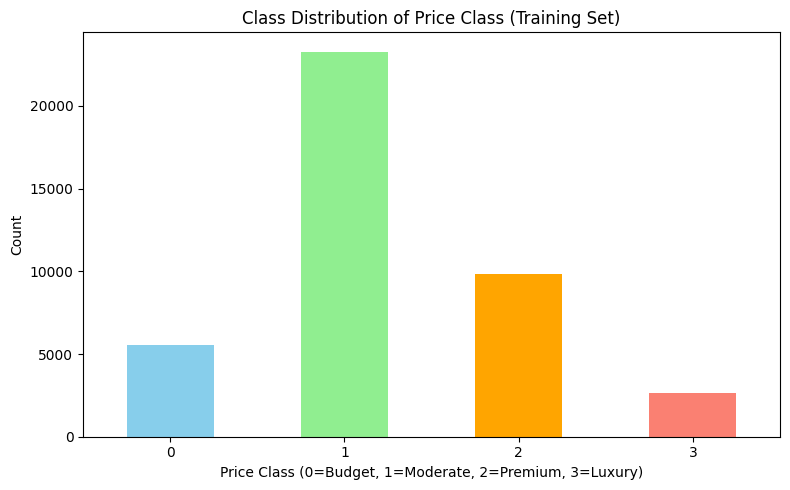


Imbalance ratio (max/min): 8.79
Dataset is imbalanced, consider class weights or sampling techniques


In [3]:
target_col = 'price_class'
class_counts = train_df[target_col].value_counts().sort_index()
print("Class counts:")
print(class_counts)
print(f"\nClass proportions:")
print(class_counts / len(train_df))

# Visualize class distribution
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'orange', 'salmon'])
plt.title('Class Distribution of Price Class (Training Set)')
plt.xlabel('Price Class (0=Budget, 1=Moderate, 2=Premium, 3=Luxury)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Check for imbalance
max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")
if imbalance_ratio > 2:
    print("Dataset is imbalanced, consider class weights or sampling techniques")
else:
    print("Dataset is relatively balanced")

# Encode categorical variables
We will use Label Encoding for categorical variables

**Justification**: Tree-based models and neural networks can handle integer encoded categoricals very well.

We will not use one-hot encoding as it  would create sparse features which might not be ideal for small dataset.

In [4]:
categorical_cols = ['neighbourhood_group', 'room_type']
print(f"Categorical columns: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col + '_encoded'] = le.fit_transform(train_df[col])
    test_df[col + '_encoded'] = le.transform(test_df[col])  # use same mapping
    label_encoders[col] = le
    print(f"\n{col} encoding:")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name} : {i}")

# Drop original categorical columns
train_df = train_df.drop(categorical_cols, axis=1)
test_df = test_df.drop(categorical_cols, axis=1)

Categorical columns: ['neighbourhood_group', 'room_type']

neighbourhood_group encoding:
  Bronx : 0
  Brooklyn : 1
  Manhattan : 2
  Queens : 3
  Staten Island : 4

room_type encoding:
  Entire home/apt : 0
  Private room : 1
  Shared room : 2


# Feature Normalization
Use StandardScaler (Z-score normalization)

**Justification**: Zero mean and unit variance helps gradient descent converge faster and prevents features with larger scales from dominating.

In [5]:
numerical_cols = ['minimum_nights', 'number_of_reviews', 'availability_365', 'amenity_score']
print(f"Numerical columns to normalize: {numerical_cols}")

scaler = StandardScaler()
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

print("\nNormalized training statistics:")
print(train_df[numerical_cols].describe())

Numerical columns to normalize: ['minimum_nights', 'number_of_reviews', 'availability_365', 'amenity_score']

Normalized training statistics:
       minimum_nights  number_of_reviews  availability_365  amenity_score
count    4.134800e+04       4.134800e+04      4.134800e+04   4.134800e+04
mean    -2.972910e-17      -3.196308e-17     -6.083296e-17   2.783022e-16
std      1.000012e+00       1.000012e+00      1.000012e+00   1.000012e+00
min     -3.025178e-01      -5.257853e-01     -8.495871e-01  -2.181308e+00
25%     -3.025178e-01      -5.030650e-01     -8.495871e-01  -7.729808e-01
50%     -1.995311e-01      -4.121839e-01     -5.126163e-01  -2.984115e-02
75%     -9.654441e-02      -3.218907e-03      8.352671e-01   7.184953e-01
max      5.113933e+01       1.326542e+01      1.945739e+00   2.443827e+00


# Visualize relationships between features and target

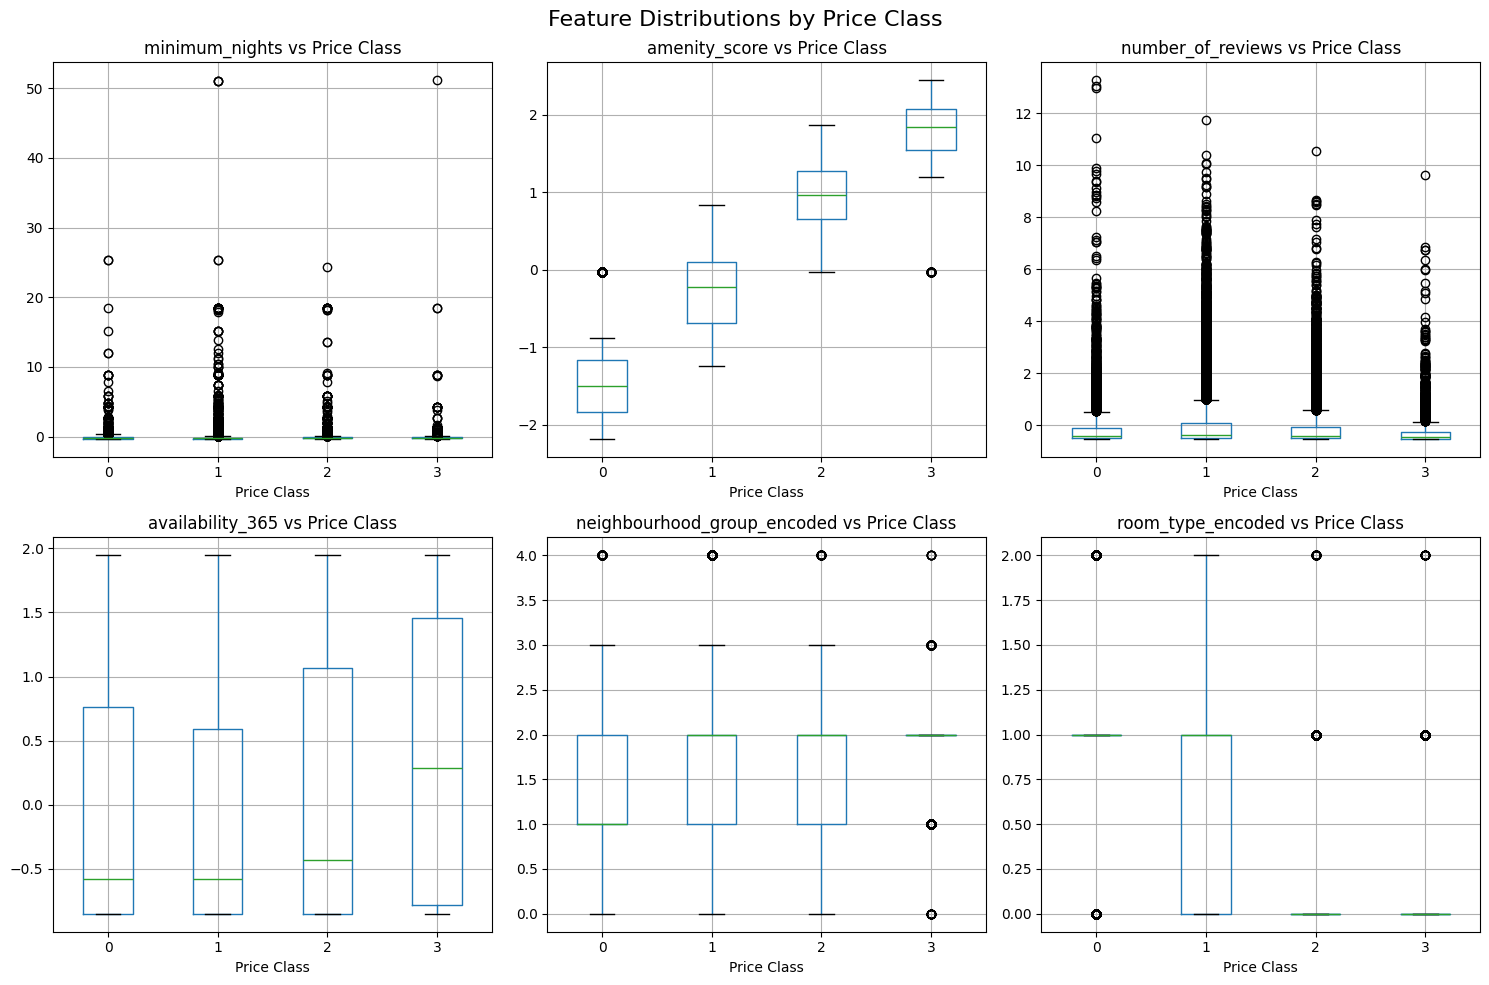

In [6]:
# Create feature list (excluding target)
feature_cols = [col for col in train_df.columns if col != target_col]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(feature_cols):
    if idx < len(axes):
        # Box plot for each feature vs target
        train_df.boxplot(column=col, by=target_col, ax=axes[idx])
        axes[idx].set_title(f'{col} vs Price Class')
        axes[idx].set_xlabel('Price Class')

plt.suptitle('Feature Distributions by Price Class', fontsize=16)
plt.tight_layout()
plt.savefig('feature_target_relationships.png', dpi=150)
plt.show()

# Correlation matrix analysis

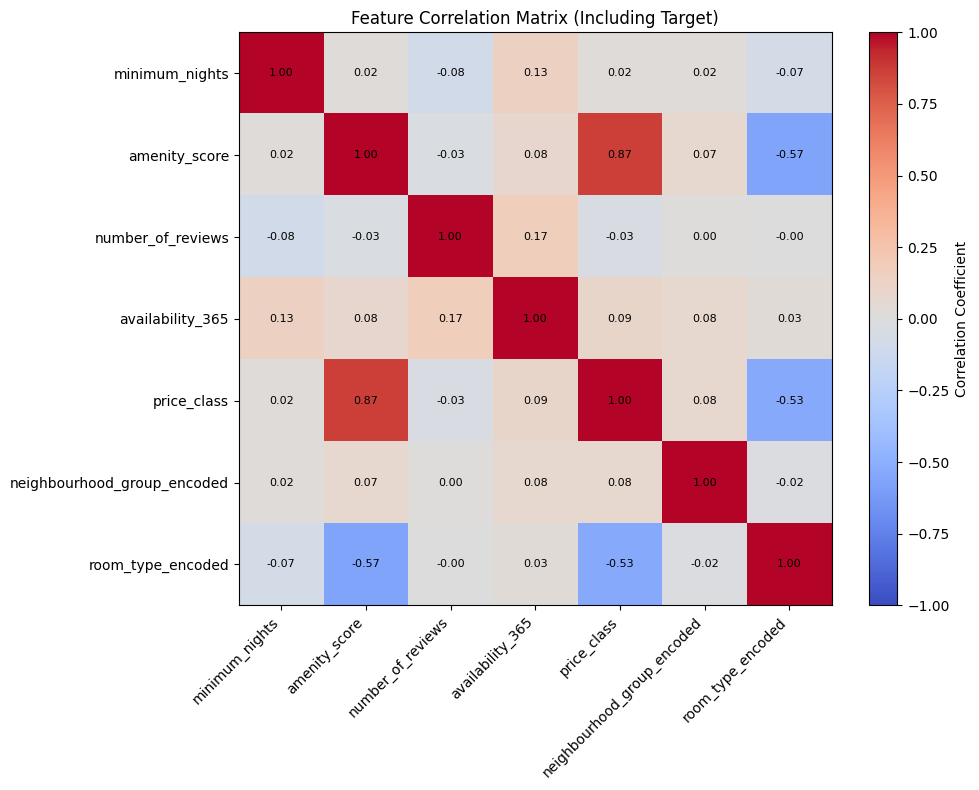


Highly correlated feature pairs (including target):
  amenity_score - price_class: 0.865


In [7]:
numerical_features_with_target = [col for col in train_df.columns if train_df[col].dtype in ['int64', 'float64', 'int32', 'float32']]
corr_matrix_with_target = train_df[numerical_features_with_target].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix_with_target, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(numerical_features_with_target)), numerical_features_with_target, rotation=45, ha='right')
plt.yticks(range(len(numerical_features_with_target)), numerical_features_with_target)
plt.title('Feature Correlation Matrix (Including Target)')

# Add correlation values as text
for i in range(len(numerical_features_with_target)):
    for j in range(len(numerical_features_with_target)):
        plt.text(j, i, f'{corr_matrix_with_target.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('correlation_matrix_with_target.png', dpi=150)
plt.show()

# Identify highly correlated pairs, including the target
print("\nHighly correlated feature pairs (including target):")
high_corr_pairs_with_target = []
for i in range(len(numerical_features_with_target)):
    for j in range(i + 1, len(numerical_features_with_target)):
        corr_val = abs(corr_matrix_with_target.iloc[i, j])
        if corr_val > 0.7:
            high_corr_pairs_with_target.append((
                numerical_features_with_target[i],
                numerical_features_with_target[j],
                corr_val
            ))
            print(f"  {numerical_features_with_target[i]} - {numerical_features_with_target[j]}: {corr_val:.3f}")

if not high_corr_pairs_with_target:
    print("  No highly correlated pairs (abs > 0.7) found")

# **Part B (a):** Two-Layer Perceptron Implemented from Scratch

# Prepare data for neural network

One-hot encoding applied to LABELS (y) - the target/output
* Required because this is a multi-class classification problem with 4 classes (0, 1, 2, 3)
* The neural network outputs 4 probabilities (one per class) via softmax
* Cross-entropy loss needs to compare predicted probabilities against true one-hot vector

In [8]:
# Separate features and target
X = train_df.drop(target_col, axis=1).values
y = train_df[target_col].values
X_test = test_df.drop(target_col, axis=1).values
y_test = test_df[target_col].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Number of features: {X.shape[1]}")

# Split training data into train and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# # Compute class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print(f"Class weights: {class_weights}")
class_weights = torch.FloatTensor(class_weights)

# Convert labels to one-hot encoding
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y.astype(int)]
num_classes = len(np.unique(y))
y_train_oh = one_hot_encode(y_train, num_classes)
y_val_oh = one_hot_encode(y_val, num_classes)
y_test_oh = one_hot_encode(y_test, num_classes)

print(f"\nOne-hot encoded labels shape: {y_train_oh.shape}")

Feature matrix shape: (41348, 6)
Target vector shape: (41348,)
Number of classes: 4
Number of features: 6

Training set: 33078 samples
Validation set: 8270 samples
Class weights: [1.85664571 0.44390466 1.05009524 3.90070755]

One-hot encoded labels shape: (33078, 4)


# Defined activation functions and their derivatives

In [9]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# def cross_entropy_loss(y_pred, y_true):
#     epsilon = 1e-15
#     y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
#     return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

def cross_entropy_loss(y_pred, y_true, class_weights=None):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Standard cross-entropy
    loss = -np.sum(y_true * np.log(y_pred), axis=1)

    if class_weights is not None:
        # Get true class indices
        true_classes = np.argmax(y_true, axis=1)
        # Multiply each sample's loss by its class weight
        sample_weights = class_weights[true_classes].numpy()
        loss = loss * sample_weights

    return np.mean(loss)

def accuracy(y_pred, y_true):
    pred_classes = np.argmax(y_pred, axis=1)
    true_classes = np.argmax(y_true, axis=1)
    return np.mean(pred_classes == true_classes)

# Initialize neural network parameters

**Network Architecture:**

    Input layer: 6 neurons
    Hidden layer 1: 64 neurons
    Hidden layer 2: 32 neurons
    Output layer: 4 neurons
    Learning rate: 0.01
    Iterations: 200


In [10]:
input_size = X_train.shape[1]
hidden_size1 = 64
hidden_size2 = 32
output_size = num_classes
learning_rate = 0.01
n_iterations = 200

print(f"\nNetwork Architecture:")
print(f"  Input layer: {input_size} neurons")
print(f"  Hidden layer 1: {hidden_size1} neurons")
print(f"  Hidden layer 2: {hidden_size2} neurons")
print(f"  Output layer: {output_size} neurons")
print(f"Learning rate: {learning_rate}")
print(f"Iterations: {n_iterations}")

# Initialize weights with Xavier initialization
np.random.seed(42)

def initialize_parameters(activation_name='relu'):
    if activation_name == 'sigmoid':
        # Xavier/Glorot - smaller variance for Sigmoid
        W1 = np.random.randn(input_size, hidden_size1) * np.sqrt(1.0 / input_size)
        W2 = np.random.randn(hidden_size1, hidden_size2) * np.sqrt(1.0 / hidden_size1)
        W3 = np.random.randn(hidden_size2, output_size) * np.sqrt(1.0 / hidden_size2)
    else:
        # He initialization - larger variance for ReLU
        W1 = np.random.randn(input_size, hidden_size1) * np.sqrt(2.0 / input_size)
        W2 = np.random.randn(hidden_size1, hidden_size2) * np.sqrt(2.0 / hidden_size1)
        W3 = np.random.randn(hidden_size2, output_size) * np.sqrt(2.0 / hidden_size2)

    b1 = np.zeros((1, hidden_size1))
    b2 = np.zeros((1, hidden_size2))
    b3 = np.zeros((1, output_size))
    return W1, b1, W2, b2, W3, b3


Network Architecture:
  Input layer: 6 neurons
  Hidden layer 1: 64 neurons
  Hidden layer 2: 32 neurons
  Output layer: 4 neurons
Learning rate: 0.01
Iterations: 200


# Forward propagation

In [11]:
def forward_propagation(X, W1, b1, W2, b2, W3, b3, activation_func):
    # Layer 1
    Z1 = np.dot(X, W1) + b1
    A1 = activation_func(Z1)

    # Layer 2
    Z2 = np.dot(A1, W2) + b2
    A2 = activation_func(Z2)

    # Output layer
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2, 'Z3': Z3, 'A3': A3}
    return A3, cache

# Back propagation

In [12]:
def backward_propagation(X, y_true, cache, W1, W2, W3, activation_derivative):
    m = X.shape[0]
    A1 = cache['A1']
    A2 = cache['A2']
    A3 = cache['A3']
    Z1 = cache['Z1']
    Z2 = cache['Z2']

    # Output layer gradient
    dZ3 = A3 - y_true
    dW3 = np.dot(A2.T, dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Hidden layer 2 gradient
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * activation_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer 1 gradient
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * activation_derivative(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    gradients = {
        'dW1': dW1, 'db1': db1,
        'dW2': dW2, 'db2': db2,
        'dW3': dW3, 'db3': db3
    }
    return gradients

# Training function with gradient tracking

In [13]:
def train_network(X_train, y_train, X_val, y_val, activation_func, activation_derivative, activation_name, class_weights=None):
    print(f"\n")
    print(f"Training with {activation_name} activation")

    # Initialize parameters
    W1, b1, W2, b2, W3, b3 = initialize_parameters(activation_name)

    # Track metrics
    train_losses = []
    train_accs = []
    val_accs = []

    # Track gradient magnitudes for each layer
    grad_magnitudes_w1 = []
    grad_magnitudes_w2 = []

    for iteration in range(n_iterations):
        # Forward propagation
        A3, cache = forward_propagation(X_train, W1, b1, W2, b2, W3, b3, activation_func)

        # Compute loss
        loss = cross_entropy_loss(A3, y_train, class_weights)
        train_losses.append(loss)

        # Compute training accuracy
        train_acc = accuracy(A3, y_train)
        train_accs.append(train_acc)

        # Validation accuracy
        A3_val, _ = forward_propagation(X_val, W1, b1, W2, b2, W3, b3, activation_func)
        val_acc = accuracy(A3_val, y_val)
        val_accs.append(val_acc)

        # Backward propagation
        gradients = backward_propagation(X_train, y_train, cache, W1, W2, W3, activation_derivative)

        # Track gradient magnitudes
        grad_mag_w1 = np.mean(np.abs(gradients['dW1']))
        grad_mag_w2 = np.mean(np.abs(gradients['dW2']))
        grad_magnitudes_w1.append(grad_mag_w1)
        grad_magnitudes_w2.append(grad_mag_w2)

        # Update parameters (vanilla gradient descent)
        W1 -= learning_rate * gradients['dW1']
        b1 -= learning_rate * gradients['db1']
        W2 -= learning_rate * gradients['dW2']
        b2 -= learning_rate * gradients['db2']
        W3 -= learning_rate * gradients['dW3']
        b3 -= learning_rate * gradients['db3']

        if iteration % 20 == 0:
            print(f"Iteration {iteration}: Loss={loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    # Final evaluation
    A3_final, _ = forward_propagation(X_train, W1, b1, W2, b2, W3, b3, activation_func)
    final_train_acc = accuracy(A3_final, y_train)
    A3_val_final, _ = forward_propagation(X_val, W1, b1, W2, b2, W3, b3, activation_func)
    final_val_acc = accuracy(A3_val_final, y_val)

    print(f"\nFinal Results ({activation_name}):")
    print(f"  Training Accuracy: {final_train_acc:.4f}")
    print(f"  Validation Accuracy: {final_val_acc:.4f}")

    parameters = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2, 'W3': W3, 'b3': b3}

    return {
        'train_accs': train_accs,
        'val_accs': val_accs,
        'train_losses': train_losses,
        'grad_w1': grad_magnitudes_w1,
        'grad_w2': grad_magnitudes_w2,
        'parameters': parameters,
        'final_train_acc': final_train_acc,
        'final_val_acc': final_val_acc
    }

In [14]:
results_sigmoid = train_network(X_train, y_train_oh, X_val, y_val_oh,
                                 sigmoid, sigmoid_derivative, "Sigmoid", class_weights=class_weights)



Training with Sigmoid activation
Iteration 0: Loss=1.4340, Train Acc=0.5091, Val Acc=0.5150
Iteration 20: Loss=1.4972, Train Acc=0.5632, Val Acc=0.5632
Iteration 40: Loss=1.5568, Train Acc=0.5632, Val Acc=0.5632
Iteration 60: Loss=1.5908, Train Acc=0.5632, Val Acc=0.5632
Iteration 80: Loss=1.6102, Train Acc=0.5632, Val Acc=0.5632
Iteration 100: Loss=1.6217, Train Acc=0.5632, Val Acc=0.5632
Iteration 120: Loss=1.6283, Train Acc=0.5632, Val Acc=0.5632
Iteration 140: Loss=1.6317, Train Acc=0.5632, Val Acc=0.5632
Iteration 160: Loss=1.6328, Train Acc=0.5632, Val Acc=0.5632
Iteration 180: Loss=1.6323, Train Acc=0.5632, Val Acc=0.5632

Final Results (Sigmoid):
  Training Accuracy: 0.5632
  Validation Accuracy: 0.5632


In [15]:
results_relu = train_network(X_train, y_train_oh, X_val, y_val_oh,
                              relu, relu_derivative, "ReLU", class_weights=class_weights)



Training with ReLU activation
Iteration 0: Loss=1.9988, Train Acc=0.1194, Val Acc=0.1150
Iteration 20: Loss=1.5511, Train Acc=0.5406, Val Acc=0.5380
Iteration 40: Loss=1.3921, Train Acc=0.6073, Val Acc=0.6105
Iteration 60: Loss=1.2954, Train Acc=0.6892, Val Acc=0.6921
Iteration 80: Loss=1.2302, Train Acc=0.7178, Val Acc=0.7162
Iteration 100: Loss=1.1786, Train Acc=0.7282, Val Acc=0.7243
Iteration 120: Loss=1.1343, Train Acc=0.7353, Val Acc=0.7325
Iteration 140: Loss=1.0952, Train Acc=0.7400, Val Acc=0.7381
Iteration 160: Loss=1.0601, Train Acc=0.7436, Val Acc=0.7416
Iteration 180: Loss=1.0276, Train Acc=0.7477, Val Acc=0.7463

Final Results (ReLU):
  Training Accuracy: 0.7511
  Validation Accuracy: 0.7495


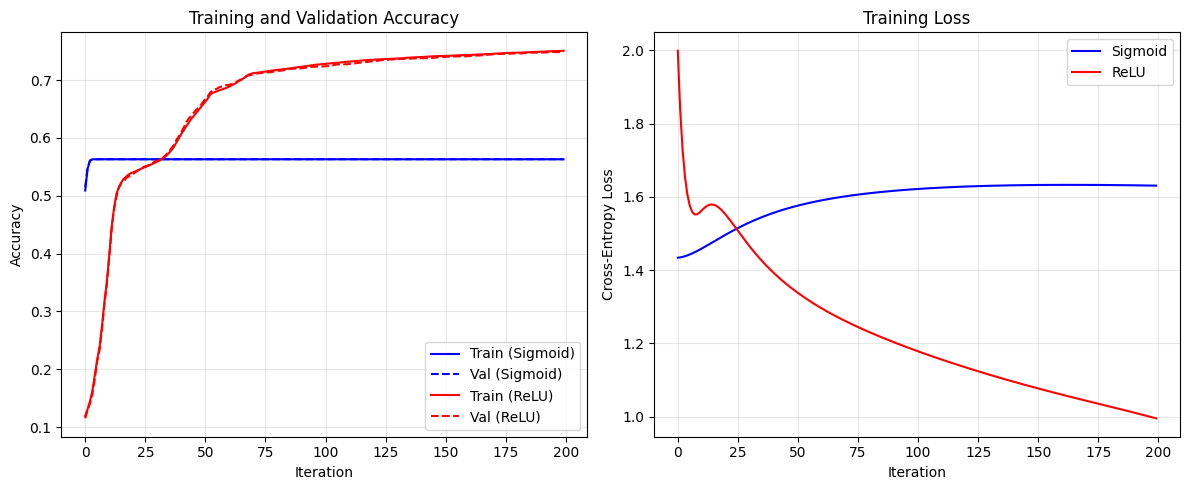

Sigmoid - Final Train Acc: 0.5632, Val Acc: 0.5632
ReLU    - Final Train Acc: 0.7511, Val Acc: 0.7495


In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_sigmoid['train_accs'], label='Train (Sigmoid)', color='blue', linestyle='-')
plt.plot(results_sigmoid['val_accs'], label='Val (Sigmoid)', color='blue', linestyle='--')
plt.plot(results_relu['train_accs'], label='Train (ReLU)', color='red', linestyle='-')
plt.plot(results_relu['val_accs'], label='Val (ReLU)', color='red', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(results_sigmoid['train_losses'], label='Sigmoid', color='blue')
plt.plot(results_relu['train_losses'], label='ReLU', color='red')
plt.xlabel('Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150)
plt.show()

print(f"Sigmoid - Final Train Acc: {results_sigmoid['final_train_acc']:.4f}, Val Acc: {results_sigmoid['final_val_acc']:.4f}")
print(f"ReLU    - Final Train Acc: {results_relu['final_train_acc']:.4f}, Val Acc: {results_relu['final_val_acc']:.4f}")

# **Part B (b):** Gradient Magnitude Comparison Across Layers

**Observations:**

Sigmoid gradients are typically smaller due to gradient vanishing (derivative max=0.25)

While, ReLU gradients are larger in early layers, helping with faster convergence

So, Gradient flow is better preserved in ReLU networks.


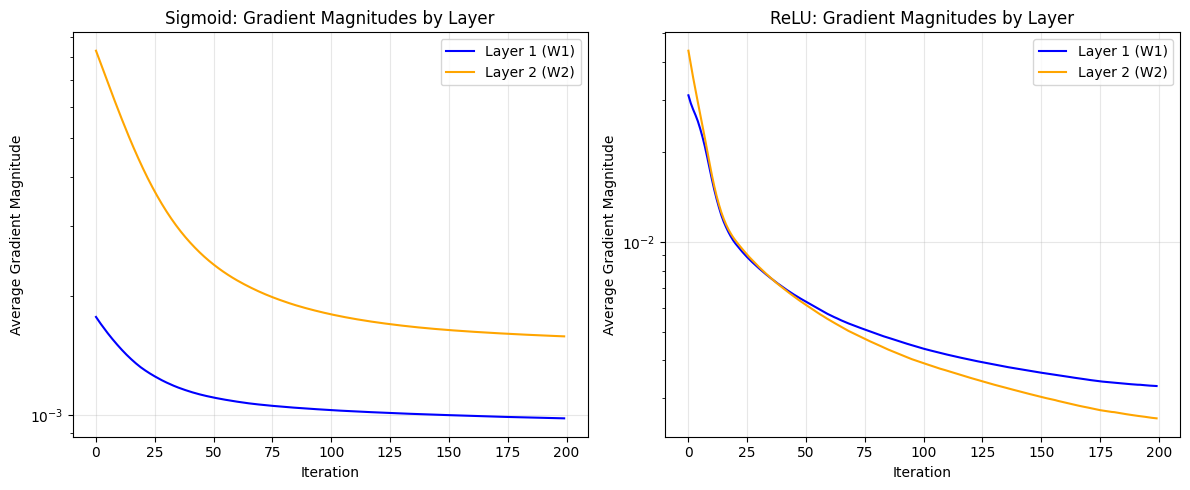


Gradient Statistics
Sigmoid:
  Layer 1 avg gradient magnitude: 0.001095
  Layer 2 avg gradient magnitude: 0.002402
  Ratio (L2/L1): 2.1948

ReLU:
  Layer 1 avg gradient magnitude: 0.006155
  Layer 2 avg gradient magnitude: 0.006030
  Ratio (L2/L1): 0.9797


In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_sigmoid['grad_w1'], label='Layer 1 (W1)', color='blue')
plt.plot(results_sigmoid['grad_w2'], label='Layer 2 (W2)', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Average Gradient Magnitude')
plt.title('Sigmoid: Gradient Magnitudes by Layer')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(results_relu['grad_w1'], label='Layer 1 (W1)', color='blue')
plt.plot(results_relu['grad_w2'], label='Layer 2 (W2)', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Average Gradient Magnitude')
plt.title('ReLU: Gradient Magnitudes by Layer')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_magnitudes.png', dpi=150)
plt.show()

# Compute statistics
print("\nGradient Statistics")
print("Sigmoid:")
print(f"  Layer 1 avg gradient magnitude: {np.mean(results_sigmoid['grad_w1']):.6f}")
print(f"  Layer 2 avg gradient magnitude: {np.mean(results_sigmoid['grad_w2']):.6f}")
print(f"  Ratio (L2/L1): {np.mean(results_sigmoid['grad_w2'])/np.mean(results_sigmoid['grad_w1']):.4f}")

print("\nReLU:")
print(f"  Layer 1 avg gradient magnitude: {np.mean(results_relu['grad_w1']):.6f}")
print(f"  Layer 2 avg gradient magnitude: {np.mean(results_relu['grad_w2']):.6f}")
print(f"  Ratio (L2/L1): {np.mean(results_relu['grad_w2'])/np.mean(results_relu['grad_w1']):.4f}")

# **Part C (b):** Implementation and Results

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to PyTorch tensors
X_train_torch = torch.FloatTensor(X_train)
y_train_torch = torch.LongTensor(y_train)
X_val_torch = torch.FloatTensor(X_val)
X_test_torch = torch.FloatTensor(X_test)
y_test_torch = torch.LongTensor(y_test)

# Define comparable PyTorch model
class TwoLayerMLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, num_classes):
        super(TwoLayerMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        out = self.fc3(h2)
        return out

# Initialize model
model = TwoLayerMLP(input_size, hidden_size1, hidden_size2, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Train the model
print("\nTraining PyTorch model...")
n_epochs = 200
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_torch)
    loss = criterion(outputs, y_train_torch)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            train_acc = (outputs.argmax(dim=1) == y_train_torch).float().mean()
            val_outputs = model(X_val_torch)
            val_acc = (val_outputs.argmax(dim=1) == torch.LongTensor(y_val)).float().mean()
        print(f"Epoch {epoch}: Loss={loss.item():.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

# Final evaluation
model.eval()
with torch.no_grad():
    train_outputs = model(X_train_torch)
    train_acc = (train_outputs.argmax(dim=1) == y_train_torch).float().mean()
    val_outputs = model(X_val_torch)
    val_acc = (val_outputs.argmax(dim=1) == torch.LongTensor(y_val)).float().mean()
    test_outputs = model(X_test_torch)
    test_acc = (test_outputs.argmax(dim=1) == y_test_torch).float().mean()

print(f"\nPyTorch Model Final Results:")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Validation Accuracy: {val_acc:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")


Training PyTorch model...
Epoch 0: Loss=1.4122, Train Acc=0.3327, Val Acc=0.3331
Epoch 20: Loss=1.3078, Train Acc=0.4172, Val Acc=0.4469
Epoch 40: Loss=1.2280, Train Acc=0.5624, Val Acc=0.5617
Epoch 60: Loss=1.1648, Train Acc=0.5633, Val Acc=0.5635
Epoch 80: Loss=1.1189, Train Acc=0.5632, Val Acc=0.5632
Epoch 100: Loss=1.0881, Train Acc=0.5632, Val Acc=0.5632
Epoch 120: Loss=1.0667, Train Acc=0.5632, Val Acc=0.5632
Epoch 140: Loss=1.0494, Train Acc=0.5632, Val Acc=0.5632
Epoch 160: Loss=1.0333, Train Acc=0.5632, Val Acc=0.5632
Epoch 180: Loss=1.0173, Train Acc=0.5632, Val Acc=0.5632

PyTorch Model Final Results:
  Training Accuracy: 0.5632
  Validation Accuracy: 0.5632
  Test Accuracy: 0.5631


# Implement Gradient-based Feature Attribution
For each correctly classified instance, compute gradients of the winning
class output with respect to input features.


Ranked Feature Importance
Rank | Feature Name | Importance Score
--------------------------------------------------
   1 | neighbourhood_group_encoded | 0.391159
   2 | amenity_score        | 0.142619
   3 | availability_365     | 0.129022
   4 | number_of_reviews    | 0.055041
   5 | room_type_encoded    | 0.029202
   6 | minimum_nights       | 0.023311


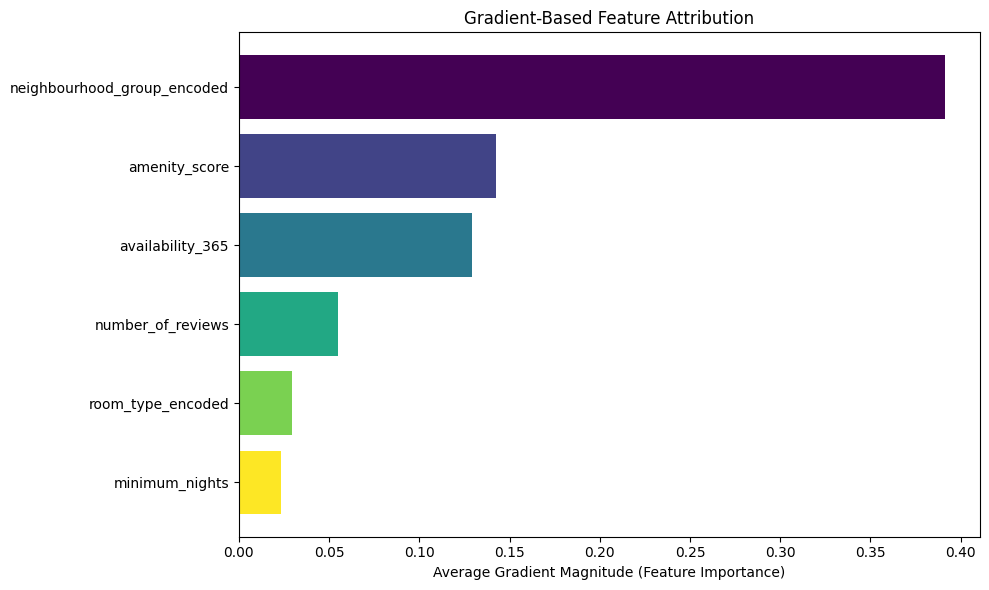

In [19]:
def compute_feature_attribution(model, X, feature_names):
    model.eval()
    X_tensor = torch.FloatTensor(X)
    X_tensor.requires_grad = True

    # Forward pass
    outputs = model(X_tensor)
    predicted_classes = outputs.argmax(dim=1)

    # Get probabilities
    probs = torch.softmax(outputs, dim=1)

    # Compute gradients for winning class of each sample
    feature_importance = np.zeros(X.shape[1])
    n_correct = 0

    for i in range(X.shape[0]):
        winning_class = predicted_classes[i].item()

        # Zero gradients
        if X_tensor.grad is not None:
            X_tensor.grad.zero_()

        # Compute gradient of winning class output w.r.t. inputs
        # We use the logit (pre-softmax) for cleaner gradients
        outputs[i, winning_class].backward(retain_graph=True)

        # Get absolute gradient
        grad = torch.abs(X_tensor.grad[i]).detach().numpy()
        feature_importance += grad
        n_correct += 1

        # Reset for next iteration
        X_tensor.grad.zero_()

    # Average over all samples
    feature_importance /= n_correct

    return feature_importance, predicted_classes.detach().numpy()

# Compute feature attribution
feature_names = [col for col in train_df.columns if col != target_col]
importance_scores, predictions = compute_feature_attribution(model, X_train, feature_names)

# Create ranked list
feature_ranking = list(zip(feature_names, importance_scores))
feature_ranking.sort(key=lambda x: x[1], reverse=True)

print("\nRanked Feature Importance")
print("Rank | Feature Name | Importance Score")
print("-" * 50)
for i, (feat, score) in enumerate(feature_ranking, 1):
    print(f"{i:4d} | {feat:20s} | {score:.6f}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
features = [f[0] for f in feature_ranking]
scores = [f[1] for f in feature_ranking]
colors = plt.cm.viridis(np.linspace(0, 1, len(features)))

plt.barh(range(len(features)), scores, color=colors)
plt.yticks(range(len(features)), features)
plt.xlabel('Average Gradient Magnitude (Feature Importance)')
plt.title('Gradient-Based Feature Attribution')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_attribution.png', dpi=150)
plt.show()

# Test Evaluation and Generalization Analysis


Test Accuracy: 0.5631
Validation Accuracy: 0.5632
Training Accuracy: 0.5632

Performance Gap Analysis:
  Train - Val: -0.0001
  Val - Test: 0.0001
  Train - Test: 0.0001

Model generalizes reasonably well.

Relation to EDA Findings
Most important features from gradient attribution:
  1. neighbourhood_group_encoded: 0.391159
  2. amenity_score: 0.142619
  3. availability_365: 0.129022

These should align with features showing strong
separation in box plots from Part A.


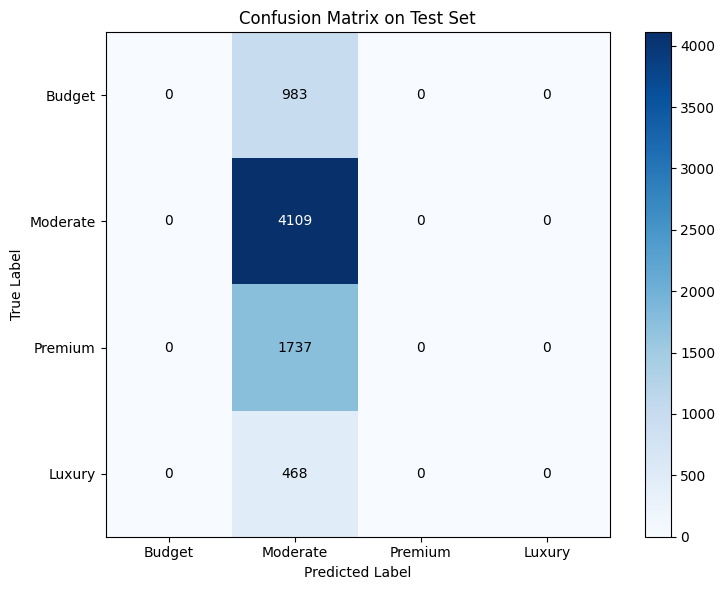


Classification Report:
              precision    recall  f1-score   support

      Budget       0.00      0.00      0.00       983
    Moderate       0.56      1.00      0.72      4109
     Premium       0.00      0.00      0.00      1737
      Luxury       0.00      0.00      0.00       468

    accuracy                           0.56      7297
   macro avg       0.14      0.25      0.18      7297
weighted avg       0.32      0.56      0.41      7297



In [20]:
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Training Accuracy: {train_acc:.4f}")

print(f"\nPerformance Gap Analysis:")
print(f"  Train - Val: {train_acc - val_acc:.4f}")
print(f"  Val - Test: {val_acc - test_acc:.4f}")
print(f"  Train - Test: {train_acc - test_acc:.4f}")

# Check for overfitting
if train_acc - test_acc > 0.1:
    print("\nSignificant overfitting detected!")
else:
    print("\nModel generalizes reasonably well.")

# Compare with EDA findings
print("\nRelation to EDA Findings")
print("Most important features from gradient attribution:")
for i, (feat, score) in enumerate(feature_ranking[:3], 1):
    print(f"  {i}. {feat}: {score:.6f}")

print("\nThese should align with features showing strong")
print("separation in box plots from Part A.")

# Confusion analysis
from sklearn.metrics import confusion_matrix, classification_report

y_pred_test = model(X_test_torch).argmax(dim=1).numpy()
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Test Set')
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, ['Budget', 'Moderate', 'Premium', 'Luxury'])
plt.yticks(tick_marks, ['Budget', 'Moderate', 'Premium', 'Luxury'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test,
                          target_names=['Budget', 'Moderate', 'Premium', 'Luxury']))